In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import colorcet as cc
from rich import print
import colorcet as cc
import matplotlib.pyplot as plt

from params import setup

In [3]:
sc.settings._vector_friendly = True

# Set SVG font type to 'none' to keep text as text in SVG files
plt.rcParams["svg.fonttype"] = "none"

In [5]:
FIGURES_DIR = "/home/nathanl/scviva_paper/merfish_brain/duplicate_region/figures_journal"

# Building the replaced adata object

In [5]:
adata = sc.read_h5ad("/home/nathanl/Data/adata_M1_M2_core_6_sections.h5ad")
# adata = sc.read_h5ad("/home/nathanl/Data/adata_astrocyte_replaced.h5ad")


target_cell_type = "astrocyte"
source_regions = ["Thalamus", "Hypothalamus"]
target_region = "Isocortex"

BATCH = "brain_section_label"
# BATCH = "sample"
LABEL = "cell_type"
SAMPLE = "brain_section_label"
# SAMPLE = "sample"
NICHE: str = "major_brain_region"
COORDS: str = "spatial"

# Count how many astrocytes are in Isocortex
n_replace = adata[adata.obs[LABEL] == target_cell_type].obs[NICHE].value_counts()[target_region]
n_replace

np.int64(7015)

In [40]:
print(adata)

AnnData object with n_obs × n_vars = 250790 × 1122
    obs: 'organism_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 
'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 
'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 
'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 
'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 
'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 
'observation_joinid', 'n_counts', 'batch', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', '_indices', '_scvi_ind_x', 'major_brain_region_banksy_astrocyte', 
'major_brain_region_banksy_endothelial', 'major_brain_region_banksy_oligodendrocyte_precursor', 
'major_brain_region_banksy_microglial', 'major_brain_region_banksy_pericyte', 
'major_brain_region_banksy_oligodendrocyte', 'major_brain_region_banksy_glutamatergic', 
'major_brain_region_banksy_GABAergic', 'cell_type_niche'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 
'feature_length', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 
'total_counts', 'log1p_total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p', 'pca', 'simvi_train_mask', 'simvi_train_mask_06', 
'simvi_train_mask_08', 'simvi_val_mask', 'simvi_val_mask_06', 'simvi_val_mask_08'
    obsm: 'X_CCF', 'X_banksy_02_harmony', 'X_banksy_02_harmony_GABAergic', 'X_banksy_02_harmony_astrocyte', 
'X_banksy_02_harmony_endothelial', 'X_banksy_02_harmony_glutamatergic', 'X_banksy_02_harmony_microglial', 
'X_banksy_02_harmony_oligodendrocyte', 'X_banksy_02_harmony_oligodendrocyte_precursor', 
'X_banksy_02_harmony_pericyte', 'X_nicheformer', 'X_nicheformer_e5', 'X_pca', 'X_resolvi', 'X_resolvi_MDE', 
'X_spatial', 'X_umap', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.0_GABAergic', 
'banksy_pc_20_lambda_0.0_astrocyte', 'banksy_pc_20_lambda_0.0_endothelial', 
'banksy_pc_20_lambda_0.0_glutamatergic', 'banksy_pc_20_lambda_0.0_microglial', 
'banksy_pc_20_lambda_0.0_oligodendrocyte', 'banksy_pc_20_lambda_0.0_oligodendrocyte_precursor', 
'banksy_pc_20_lambda_0.0_pericyte', 'banksy_pc_20_lambda_0.2', 'banksy_pc_20_lambda_0.2_GABAergic', 
'banksy_pc_20_lambda_0.2_astrocyte', 'banksy_pc_20_lambda_0.2_endothelial', 
'banksy_pc_20_lambda_0.2_glutamatergic', 'banksy_pc_20_lambda_0.2_microglial', 
'banksy_pc_20_lambda_0.2_oligodendrocyte', 'banksy_pc_20_lambda_0.2_oligodendrocyte_precursor', 
'banksy_pc_20_lambda_0.2_pericyte', 'banksy_pc_20_lambda_0.4', 'banksy_pc_20_lambda_0.4_astrocyte', 
'banksy_pc_20_lambda_0.5', 'banksy_pc_20_lambda_0.6', 'distance_neighbor', 'index_neighbor', 'simvi25_all_mae_50', 
'simvi25_all_mae_80', 'simvi25_both_mae_50', 'simvi25_both_mae_80', 'simvi25_interact_mae_50', 
'simvi25_interact_mae_80', 'simvi25_intrinsic_mae_50', 'simvi25_intrinsic_mae_80', 'simvi_both', 'simvi_both_06', 
'simvi_both_07', 'simvi_both_08', 'simvi_both_MDE', 'simvi_both_MDE_06', 'simvi_both_MDE_07', 'simvi_both_MDE_08', 
'simvi_interact', 'simvi_interact_06', 'simvi_interact_07', 'simvi_interact_08', 'simvi_interact_MDE', 
'simvi_interact_MDE_06', 'simvi_interact_MDE_07', 'simvi_interact_MDE_08', 'simvi_intrinsic', 'simvi_intrinsic_06',
'simvi_intrinsic_07', 'simvi_intrinsic_08', 'simvi_intrinsic_MDE', 'simvi_intrinsic_MDE_06', 
'simvi_intrinsic_MDE_07', 'simvi_intrinsic_MDE_08', 'spatial'
    varm: 'PCs'
    layers: 'counts'

In [41]:
# adata_seed = adata.copy()

# keys_to_remove = [
#     "simvi_both",
#     "simvi_both_06",
#     "simvi_both_07",
#     "simvi_both_08",
#     "simvi_both_MDE",
#     "simvi_both_MDE_06",
#     "simvi_both_MDE_07",
#     "simvi_both_MDE_08",
#     "simvi_interact",
#     "simvi_interact_06",
#     "simvi_interact_07",
#     "simvi_interact_08",
#     "simvi_interact_MDE",
#     "simvi_interact_MDE_06",
#     "simvi_interact_MDE_07",
#     "simvi_interact_MDE_08",
#     "simvi_intrinsic",
#     "simvi_intrinsic_06",
#     "simvi_intrinsic_07",
#     "simvi_intrinsic_08",
#     "simvi_intrinsic_MDE",
#     "simvi_intrinsic_MDE_06",
#     "simvi_intrinsic_MDE_07",
#     "simvi_intrinsic_MDE_08",
#     # "X_banksy_02_harmony",
#     "X_banksy_02_harmony_GABAergic",
#     "X_banksy_02_harmony_astrocyte",
#     "X_banksy_02_harmony_endothelial",
#     "X_banksy_02_harmony_glutamatergic",
#     "X_banksy_02_harmony_microglial",
#     "X_banksy_02_harmony_oligodendrocyte",
#     "X_banksy_02_harmony_oligodendrocyte_precursor",
#     "X_banksy_02_harmony_pericyte",
#     "X_nicheformer",
#     "X_nicheformer_e5",
#     # "X_pca",
#     # "X_resolvi",
#     "X_resolvi_MDE",
#     # "X_spatial",
#     "X_umap",
#     "banksy_pc_20_lambda_0.0",
#     "banksy_pc_20_lambda_0.0_GABAergic",
#     "banksy_pc_20_lambda_0.0_astrocyte",
#     "banksy_pc_20_lambda_0.0_endothelial",
#     "banksy_pc_20_lambda_0.0_glutamatergic",
#     "banksy_pc_20_lambda_0.0_microglial",
#     "banksy_pc_20_lambda_0.0_oligodendrocyte",
#     "banksy_pc_20_lambda_0.0_oligodendrocyte_precursor",
#     "banksy_pc_20_lambda_0.0_pericyte",
#     # "banksy_pc_20_lambda_0.2",
#     "banksy_pc_20_lambda_0.2_GABAergic",
#     "banksy_pc_20_lambda_0.2_astrocyte",
#     "banksy_pc_20_lambda_0.2_endothelial",
#     "banksy_pc_20_lambda_0.2_glutamatergic",
#     "banksy_pc_20_lambda_0.2_microglial",
#     "banksy_pc_20_lambda_0.2_oligodendrocyte",
#     "banksy_pc_20_lambda_0.2_oligodendrocyte_precursor",
#     "banksy_pc_20_lambda_0.2_pericyte",
#     "banksy_pc_20_lambda_0.4",
#     "banksy_pc_20_lambda_0.4_astrocyte",
#     # "banksy_pc_20_lambda_0.5",
#     # "banksy_pc_20_lambda_0.6",
#     # "distance_neighbor",
#     # "index_neighbor",
#     "simvi25_all_mae_50",
#     "simvi25_all_mae_80",
#     "simvi25_both_mae_50",
#     "simvi25_both_mae_80",
#     "simvi25_interact_mae_50",
#     "simvi25_interact_mae_80",
#     "simvi25_intrinsic_mae_50",
#     "simvi25_intrinsic_mae_80",
#     # "spatial",
# ]

# for key in keys_to_remove:
#     if key in adata.obsm:
#         del adata.obsm[key]


# print(adata)

# # adata_seed.write_h5ad("/home/nathanl/Data/adata_astrocyte_replaced.h5ad")

In [5]:
# from harmony import harmonize

# adata.obsm["X_banksy_02_harmony"] = harmonize(adata.obsm["banksy_pc_20_lambda_0.2"], adata.obs, batch_key=setup.BATCH)
# adata.write_h5ad("/home/nathanl/Data/adata_M1_M2_core_6_sections.h5ad")

In [6]:
# for sample in adata.obs[setup.SAMPLE].unique().tolist()[1:2]:
#     sc.pl.spatial(
#         adata[(adata.obs[setup.SAMPLE] == sample) & (adata.obs[setup.CELL_TYPE].isin(["glutamatergic neuron"]))],
#         spot_size=40,
#         color=[setup.NICHE],
#         # color=[setup.CELL_TYPE],
#         ncols=1,
#         frameon=False,
#         title=sample,
#         # palette="tab10",
#         palette=cc.glasbey_light,
#         show=False,
#     )

# #     plt.savefig(f"{figure_dir}brain_section_niche.png", bbox_inches="tight", dpi=1000)
#     plt.savefig(f"{setup.FIGURES_FOLDER}brain_section_gluta__niche.svg", bbox_inches="tight", dpi=10)

In [42]:
adata[adata.obs[LABEL].isin(["astrocyte"])].obs[NICHE].value_counts()

major_brain_region
Isocortex              7015
Thalamus               5117
Hypothalamus           3896
Fiber_tracts           3715
Striatum               3459
Hippocampus            2251
Olfactory              1787
Cortical_subplate      1092
Pallidum                978
Ventricular_systems     546
Name: count, dtype: int64

In [43]:
import numpy as np
import anndata as ad
import scanpy as sc
import pandas as pd

# Parameters
target_cell_type = "astrocyte"
source_regions = ["Thalamus", "Hypothalamus"]
target_region = "Isocortex"
BATCH = "brain_section_label"
LABEL = "cell_type"
SAMPLE = "brain_section_label"
NICHE = "major_brain_region"
COORDS = "spatial"
n_sampled_per_batch = 500  # you can reduce or raise this as needed

# Load data
# adata = sc.read_h5ad("/home/nathanl/Data/adata_M1_M2_core_6_sections.h5ad")
adata.obs["replacement_status"] = "untouched"  # default

# Collectors
all_astro_sampled = []
all_source_original = []
all_replaced_ids = []

# Iterate over each brain section (slide)
for batch in adata.obs[BATCH].unique():
    print(f"\nProcessing batch: {batch}")
    batch_mask = adata.obs[BATCH] == batch

    # --- Select astrocytes in Isocortex (target) and source regions (Thalamus, Hypothalamus)
    target_astro_mask = (adata.obs[LABEL] == target_cell_type) & (adata.obs[NICHE] == target_region) & batch_mask
    source_astro_mask = (adata.obs[LABEL] == target_cell_type) & (adata.obs[NICHE].isin(source_regions)) & batch_mask

    target_astro = adata[target_astro_mask].copy()
    source_astro = adata[source_astro_mask].copy()

    n_target = target_astro.shape[0]
    n_source = source_astro.shape[0]
    print(f"  n_target={n_target}, n_source={n_source}")

    if n_target < 1 or n_source < 1:
        print("  Skipping batch (not enough target/source astrocytes)")
        continue

    n_sampled = min(n_sampled_per_batch, n_target, n_source)
    print(f"  Sampling {n_sampled} cells for replacement")

    # --- Sample target and source cells randomly
    target_ids = np.random.choice(target_astro.obs_names, n_sampled, replace=False)
    target_subset = target_astro[target_ids].copy()

    sampled_ids = np.random.choice(source_astro.obs_names, n_sampled, replace=False)
    astro_sampled = source_astro[sampled_ids].copy()
    source_original = astro_sampled.copy()

    # # --- Replace expression and spatial coordinates
    # astro_sampled.X = target_subset.X.copy()
    # if "counts" in adata.layers:
    #     astro_sampled.layers["counts"] = target_subset.layers["counts"].copy()
    # if isinstance(target_subset.raw, ad.AnnData):
    #     astro_sampled.raw = ad.AnnData(X=astro_sampled.X, var=target_subset.var)

    astro_sampled.obsm[COORDS] = target_subset.obsm[COORDS].copy()

    # --- Metadata updates
    astro_sampled.obs[NICHE] = target_region
    astro_sampled.obs[BATCH] = batch
    astro_sampled.obs[SAMPLE] = batch
    astro_sampled.obs_names = [f"{idx}_replaced" for idx in sampled_ids]
    astro_sampled.obs["replacement_status"] = "duplicated"

    source_original.obs["replacement_status"] = "original"

    # --- Untouched target astrocytes (not replaced)
    target_unused_ids = list(set(target_astro.obs_names) - set(target_ids))
    adata.obs.loc[target_unused_ids, "replacement_status"] = "untouched"

    # --- Track replaced cells for removal
    all_replaced_ids.extend(target_ids)
    all_astro_sampled.append(astro_sampled)
    all_source_original.append(source_original)

# --- Remove replaced target astrocytes
adata = adata[~adata.obs_names.isin(all_replaced_ids)].copy()

# --- Remove source astrocytes that were sampled (originals)
from functools import reduce

sampled_source_ids = reduce(
    lambda x, y: x.union(y), [a.obs_names.str.replace("_replaced", "", regex=False) for a in all_astro_sampled]
)
adata = adata[~adata.obs_names.isin(sampled_source_ids)].copy()

# --- Final combined AnnData
adata_displaced = ad.concat([adata] + all_source_original + all_astro_sampled, axis=0)
print(f"\nFinal shape after per-batch displacement: {adata_displaced.shape}")

Processing batch: C57BL6J-1.074

n_target=1074, n_source=1263

Sampling 500 cells for replacement

Processing batch: C57BL6J-1.077

n_target=1255, n_source=1610

...

Sampling 500 cells for replacement

Processing batch: C57BL6J-2.037

n_target=1088, n_source=1502

Sampling 500 cells for replacement

Final shape after per-batch displacement: (250790, 1122)

/tmp/ipykernel_1417032/3306094504.py:9: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/nathanl/miniforge3/envs/scvi/lib/python3.12/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


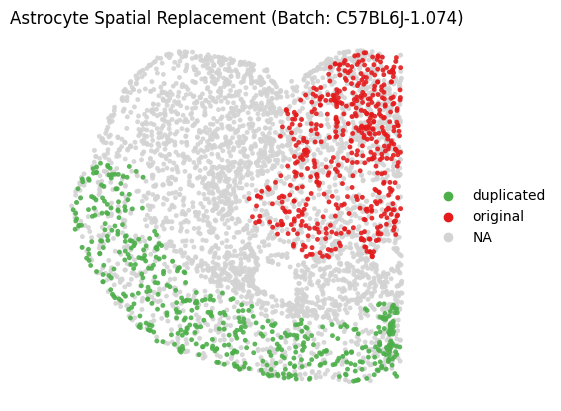

In [7]:
# Pick one batch to plot
batch_to_plot = adata_displaced.obs[BATCH].unique()[0]
plot_mask = (
    (adata_displaced.obs[BATCH] == batch_to_plot)
    & (adata_displaced.obs[LABEL] == target_cell_type)
    & (adata_displaced.obs["replacement_status"].isin(["original", "duplicated", "untouched"]))
)

sc.pl.spatial(
    adata_displaced[plot_mask],
    color="replacement_status",
    size=1.5,
    alpha=0.9,
    spot_size=50,
    groups=[
        "duplicated",
        "original",
    ],
    title=f"Astrocyte Spatial Replacement (Batch: {batch_to_plot})",
    palette=["#4daf4a","#e41a1c", "#984ea3"],  # red, green, purple
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURES_DIR}/astrocyte_spatial_replacement_{batch_to_plot}.svg", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURES_DIR}/astrocyte_spatial_replacement_{batch_to_plot}.png", bbox_inches="tight", dpi=300)

In [120]:
adata_displaced.obs_names

Index(['99119258951401284221813451836785008968-0',
       '95610536408155075407048305276227824006-0',
       '94627996433995692958551448758698866723-0',
       '10618021078266319649091845116122351158-0',
       '89038554173344823793949504602728291142-0',
       '125648933759248875202902058345534695696-0',
       '7980804522062058468602127765898854073-0',
       '78922520675900367776551089328852017621-0',
       '77185468572894437014015351891110308733-0',
       '114819608734576877403651465886313074189-0',
       ...
       '30753943164642882308091000001942703674-1_replaced',
       '64216057958901994339459473615822880172-1_replaced',
       '65889695716971761783494751611101008066-1_replaced',
       '61065785866820091474073430615810768005-1_replaced',
       '8836461515548074241832646169875393528-1_replaced',
       '67595379353956854180146125390506309267-1_replaced',
       '39250705849732277499853951095182597136-1_replaced',
       '206761293650636939936520673588813698706-1_replaced'

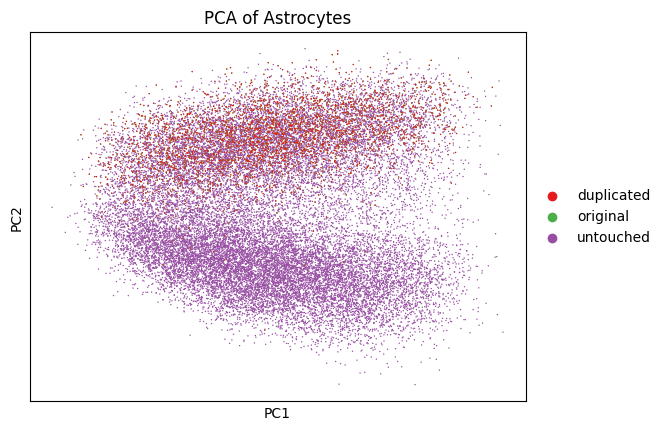

In [121]:
# run PCA then generate UMAP plots
adata_displaced_target_type = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
sc.tl.pca(adata_displaced_target_type, svd_solver="arpack")
sc.pl.pca(
    adata_displaced_target_type,
    color="replacement_status",
    title="PCA of Astrocytes",
    palette=["#e41a1c", "#4daf4a", "#984ea3"],
)
sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)

In [122]:
adata_displaced_target_type.obs["replacement_status"].value_counts()

replacement_status
untouched     23856
duplicated     3000
original       3000
Name: count, dtype: int64

In [123]:
# Compute MSE
from sklearn.metrics import mean_squared_error

# Filter only astrocytes
adata_subset = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
duplicated = adata_subset[adata_subset.obs["replacement_status"] == "duplicated"]
original_ids = [idx.replace("_replaced", "") for idx in duplicated.obs_names]
original = adata_subset[original_ids]
mse = mean_squared_error(
    original.X.A if hasattr(original.X, "A") else original.X,
    duplicated.X.A if hasattr(duplicated.X, "A") else duplicated.X,
)
print(f"MSE between duplicated and original expression profiles:\n{mse:.6f}")

MSE between duplicated and original expression profiles:
0.000000

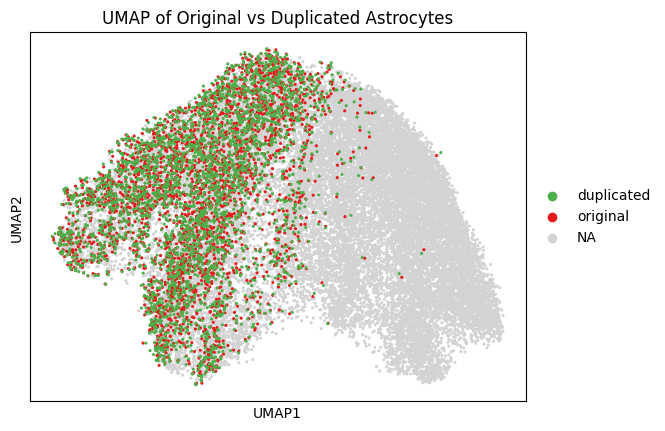

In [124]:
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

In [126]:
# adata_displaced.write_h5ad("/home/nathanl/Data/adata_astrocyte_replaced.h5ad")

# results after training the models on the replaced adata object

In [7]:
target_cell_type = "astrocyte"
source_regions = ["Thalamus", "Hypothalamus"]
target_region = "Isocortex"

BATCH = "brain_section_label"
# BATCH = "sample"
SAMPLE = "brain_section_label"
# SAMPLE = "sample"
NICHE: str = "major_brain_region"
COORDS: str = "spatial"
LABEL = "cell_type"


adata_displaced = ad.read_h5ad(
    "/home/nathanl/scviva_paper/merfish_brain/checkpoints/adata_astrocyte_replaced/adata_astrocyte_replaced_nicheVI.h5ad"
)  # universal-runner output; was the input file written in place by the old duplicate runner
adata_displaced_target_type = adata_displaced[adata_displaced.obs[LABEL] == target_cell_type].copy()
print(adata_displaced)

AnnData object with n_obs × n_vars = 250790 × 1122
    obs: 'organism_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 
'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 
'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 
'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 
'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 
'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 
'observation_joinid', 'n_counts', 'batch', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', '_indices', '_scvi_ind_x', 'major_brain_region_banksy_astrocyte', 
'major_brain_region_banksy_endothelial', 'major_brain_region_banksy_oligodendrocyte_precursor', 
'major_brain_region_banksy_microglial', 'major_brain_region_banksy_pericyte', 
'major_brain_region_banksy_oligodendrocyte', 'major_brain_region_banksy_glutamatergic', 
'major_brain_region_banksy_GABAergic', 'cell_type_niche', 'replacement_status', 'index', '_scvi_sample', 
'astrocyte_s10_scanvi_lr0.0005_poisson_compo_error', 'astrocyte_s10_scanvi_lr0.0005_poisson_niche_error'
    var: 'mt'
    uns: '_scvi_manager_uuid', '_scvi_uuid'
    obsm: 'X_CCF', 'X_banksy_02_harmony', 'X_banksy_06_harmony', 'X_pca', 'X_resolvi', 'X_scanvi', 'X_spatial', 
'astrocyte_s10_scanvi_lr0.0005_poisson_X_nicheVI', 'banksy_pc_20_lambda_0.0', 'banksy_pc_20_lambda_0.2', 
'banksy_pc_20_lambda_0.5', 'banksy_pc_20_lambda_0.6', 'distance_neighbor', 'index_neighbor', 
'neighborhood_composition', 'niche_distances', 'niche_indexes', 'qz1_m', 'qz1_m_niche_ct', 'simvi25_all_mae_50', 
'simvi25_both_mae_50', 'simvi25_interact_mae_50', 'simvi25_intrinsic_mae_50', 'spatial'
    layers: 'counts'

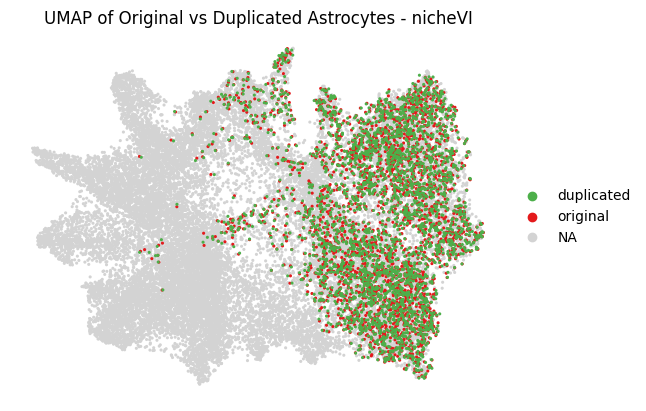

In [6]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="astrocyte_s10_scanvi_lr0.0005_poisson_X_nicheVI")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes - nicheVI",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_nicheVI.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_nicheVI.svg", bbox_inches="tight", dpi=300)

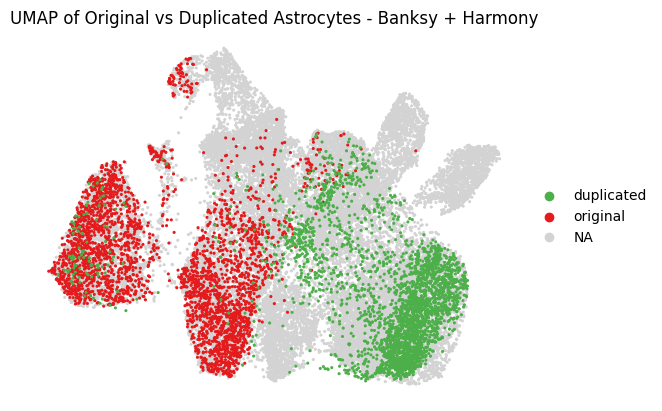

In [7]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="X_banksy_02_harmony")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes - Banksy + Harmony",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_banksy_harmony.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_banksy_harmony.svg", bbox_inches="tight", dpi=300)

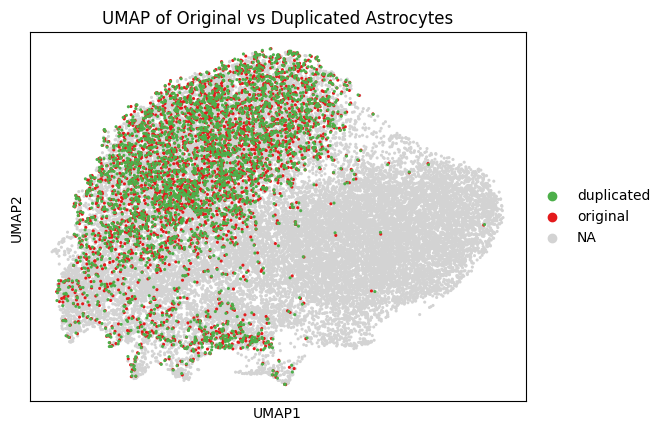

In [63]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_intrinsic_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

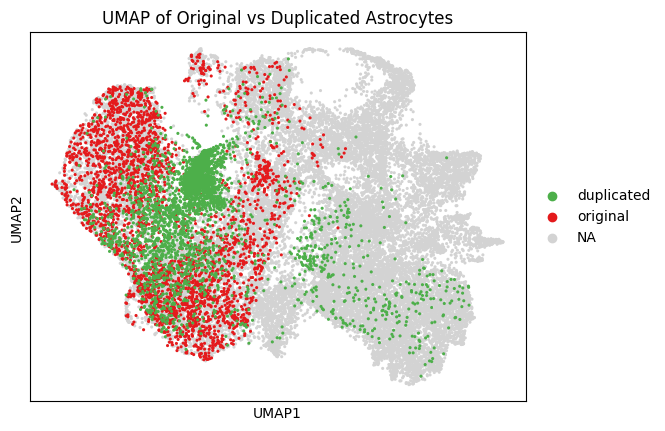

In [65]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_interact_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

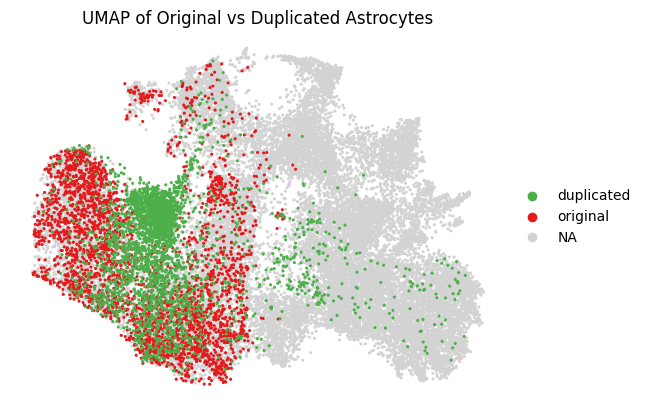

In [8]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_all_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_simvi_all.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_simvi_all.svg", bbox_inches="tight", dpi=300)

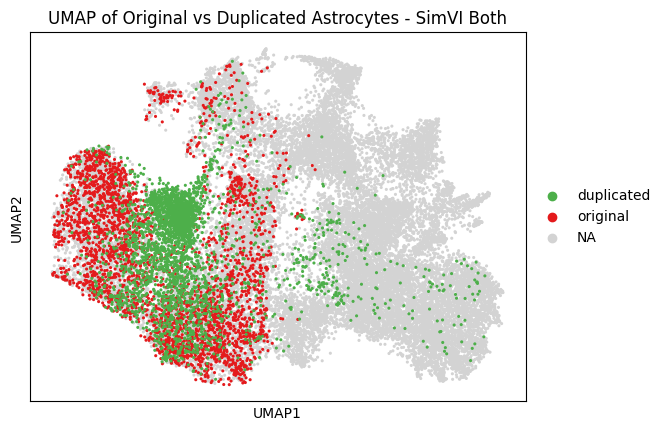

In [9]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="simvi25_both_mae_50")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes - SimVI Both",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
)

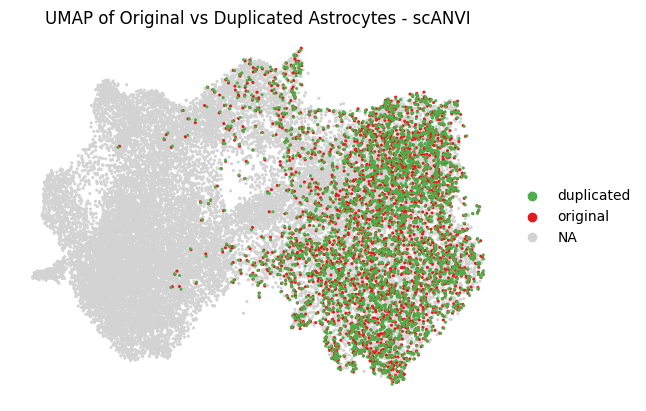

In [10]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="X_scanvi")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes - scANVI",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
    frameon=False,
    show=False,
)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_scanvi.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURES_DIR}/astrocyte_umap_scanvi.svg", bbox_inches="tight", dpi=300)

In [11]:
# 1. BANKSY-harmony + scANVI concatenation
adata_displaced_target_type.obsm["X_banksy_harmony_scanvi_concat"] = np.concatenate(
    [adata_displaced_target_type.obsm["X_banksy_02_harmony"], adata_displaced_target_type.obsm["X_scanvi"]], axis=1
)

# 2. SIMVI-all + scANVI concatenation
adata_displaced_target_type.obsm["X_simvi_all_scanvi_concat"] = np.concatenate(
    [adata_displaced_target_type.obsm["simvi25_both_mae_50"], adata_displaced_target_type.obsm["X_scanvi"]], axis=1
)

<Axes: title={'center': 'UMAP of Original vs Duplicated Astrocytes - Concat(BANKSY, scANVI)'}, xlabel='UMAP1', ylabel='UMAP2'>

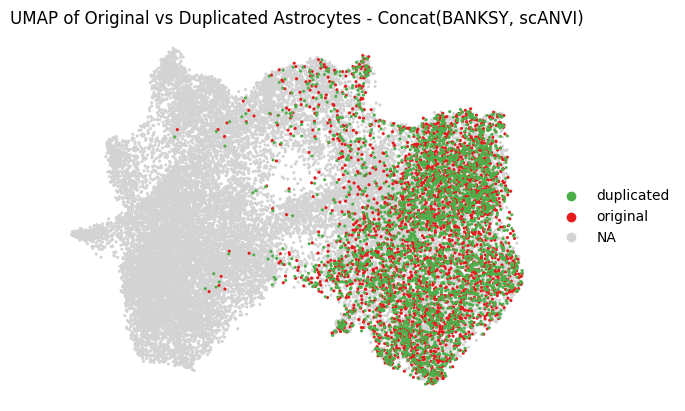

In [9]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="X_simvi_all_scanvi_concat")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes - Concat(BANKSY, scANVI)",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
    frameon=False,
    show=False,
)

<Axes: title={'center': 'UMAP of Original vs Duplicated Astrocytes - Concat(BANKSY, scANVI)'}, xlabel='UMAP1', ylabel='UMAP2'>

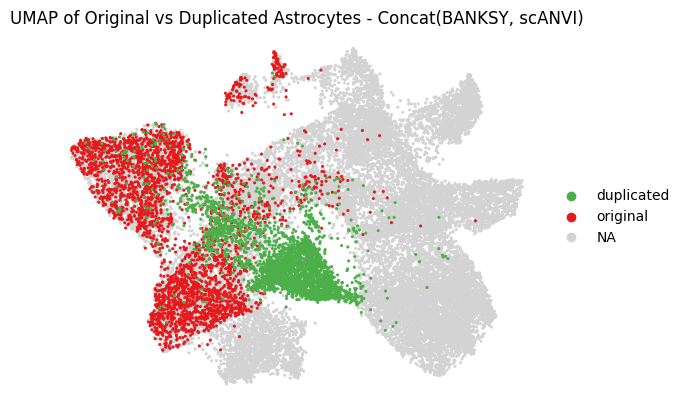

In [ ]:
# sc.pp.neighbors(adata_displaced_target_type, n_pcs=30, n_neighbors=20)
sc.pp.neighbors(adata_displaced_target_type, n_neighbors=20, use_rep="X_banksy_harmony_scanvi_concat")
sc.tl.umap(adata_displaced_target_type, min_dist=0.3)
# Plot
sc.pl.umap(
    adata_displaced_target_type,
    color="replacement_status",
    title="UMAP of Original vs Duplicated Astrocytes - Concat(BANKSY, scANVI)",
    palette=["#4daf4a", "#e41a1c"],  # original green, duplicated red
    groups=["original", "duplicated"],
    size=20,
    frameon=False,
    show=False,
)

In [66]:
# adata_seed = ad.read_h5ad("/home/nathanl/Data/adata_M1_M2_core_6_sections_seed.h5ad")
# adata_seed_target_type = adata_seed[adata_seed.obs[LABEL] == target_cell_type].copy()
# print(adata_seed)

In [12]:
adata_displaced_target_type.obs["replacement_status"].value_counts()

replacement_status
untouched     23856
duplicated     3000
original       3000
Name: count, dtype: int64

In [9]:
from nichevi.spatial_analysis import _integration_lisi, _lisi_per_cell_type

adata_untouched_duplicated = adata_displaced_target_type[
    adata_displaced_target_type.obs["replacement_status"].isin(["untouched", "duplicated"])
].copy()
for embedding in [
    "X_scanvi",
    "X_banksy_02_harmony",
    "astrocyte_s10_scanvi_lr0.0005_poisson_X_nicheVI",
    "simvi25_intrinsic_mae_50",
    "simvi25_interact_mae_50",
    "simvi25_both_mae_50",
    # "X_simvi_all_scanvi_concat",
    # "X_banksy_harmony_scanvi_concat",
    
]:
    adata_untouched_duplicated.obs["iLISI_" + embedding] = _integration_lisi(
        adata_untouched_duplicated,
        embedding_key=embedding,
        label_key="replacement_status",
        n_neighbors=90,
        perplexity=30,
    )

Computing iLISI for X_scanvi based on replacement_status
Number of batches: 2
Min 0.9999988 Max 2.0000005
Median iLISI: 0.015458345
Mean iLISI: 0.252003
Computing iLISI for X_banksy_02_harmony based on replacement_status
Number of batches: 2
Min 0.9999988 Max 1.9999988
Median iLISI: 0.0043465495
Mean iLISI: 0.12467801
Computing iLISI for astrocyte_s10_scanvi_lr0.0005_poisson_X_nicheVI based on replacement_status
Number of batches: 2
Min 0.9999988 Max 2.0000002
Median iLISI: 0.011163771
Mean iLISI: 0.2442451
Computing iLISI for simvi25_intrinsic_mae_50 based on replacement_status
Number of batches: 2
Min 0.99999857 Max 2.0000002
Median iLISI: 0.06260133
Mean iLISI: 0.26286995
Computing iLISI for simvi25_interact_mae_50 based on replacement_status
Number of batches: 2
Min 0.9999988 Max 2.0
Median iLISI: 0.004080653
Mean iLISI: 0.100983
Computing iLISI for simvi25_both_mae_50 based on replacement_status
Number of batches: 2
Min 0.9999988 Max 1.9999998
Median iLISI: 5.9604645e-07
Mean iLIS

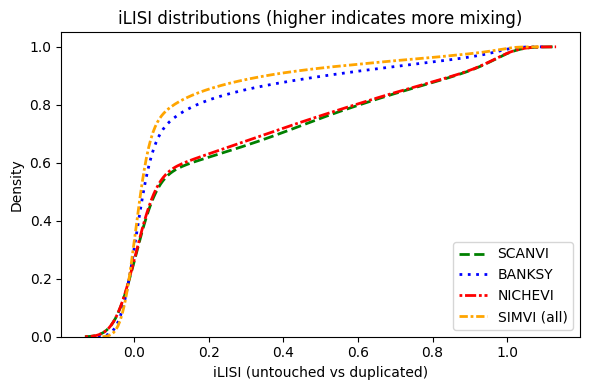

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define styling per method
styles = {
    "SCANVI": {"color": "green", "linestyle": "--"},
    "BANKSY": {"color": "blue", "linestyle": (0, (1, 2))},
    "NICHEVI": {"color": "red", "linestyle": (0, (1, 1, 4, 1))},
    "SIMVI (all)": {"color": "orange", "linestyle": (0, (3, 1, 1, 1))},
    "SIMVI (interact)": {"color": "brown", "linestyle": (0, (3, 5, 1, 5))},
    "SIMVI (intrinsic)": {"color": "pink", "linestyle": (0, (5, 5))},
}


# Map from plot label → obs key in adata
method_to_obsm = {
    "SCANVI": "iLISI_X_scanvi",
    "BANKSY": "iLISI_X_banksy_02_harmony",
    "NICHEVI": "iLISI_astrocyte_s10_scanvi_lr0.0005_poisson_X_nicheVI",
    "SIMVI (all)": "iLISI_simvi25_both_mae_50",
    # "SIMVI (interact)": "iLISI_simvi25_interact_mae_50",
    # "SIMVI (intrinsic)": "iLISI_simvi25_intrinsic_mae_50",
}

plt.figure(figsize=(6, 4))

for method, key in method_to_obsm.items():
    values = adata_untouched_duplicated.obs[key].dropna()
    sns.kdeplot(
        values,
        label=method,
        color=styles[method]["color"],
        linestyle=styles[method]["linestyle"],
        linewidth=2,
        common_norm=True,
        cumulative=True,  # or True if you want CDF
        # cumulative=False,  # or True if you want CDF
    )

plt.xlabel("iLISI (untouched vs duplicated)")
plt.ylabel("Density")
plt.title("iLISI distributions (higher indicates more mixing)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/astrocyte_ilisi_comparison.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURES_DIR}/astrocyte_ilisi_comparison.svg", bbox_inches="tight", dpi=300)
plt.show()

# loss analysis 

In [12]:
adata_displaced.obs["astrocyte_s10_scanvi_lr0.0005_poisson_niche_error"]

99119258951401284221813451836785008968-0               95.303162
95610536408155075407048305276227824006-0              119.205734
94627996433995692958551448758698866723-0              135.887344
10618021078266319649091845116122351158-0               89.354225
89038554173344823793949504602728291142-0               74.803444
                                                         ...    
67595379353956854180146125390506309267-1_replaced     134.588623
39250705849732277499853951095182597136-1_replaced     153.216064
206761293650636939936520673588813698706-1_replaced     86.609619
315721019508776688166787623879994109775-1_replaced    110.685883
32766862878815022606253158649218735577-1_replaced     104.750137
Name: astrocyte_s10_scanvi_lr0.0005_poisson_niche_error, Length: 250790, dtype: float32

In [13]:
adata_displaced.obs["astrocyte_s10_scanvi_lr0.0005_poisson_compo_error"]

99119258951401284221813451836785008968-0             -112.861633
95610536408155075407048305276227824006-0             -105.327972
94627996433995692958551448758698866723-0              -96.516136
10618021078266319649091845116122351158-0             -114.781479
89038554173344823793949504602728291142-0             -124.899727
                                                         ...    
67595379353956854180146125390506309267-1_replaced    -116.014908
39250705849732277499853951095182597136-1_replaced    -114.563660
206761293650636939936520673588813698706-1_replaced   -124.675102
315721019508776688166787623879994109775-1_replaced   -122.554062
32766862878815022606253158649218735577-1_replaced    -115.557724
Name: astrocyte_s10_scanvi_lr0.0005_poisson_compo_error, Length: 250790, dtype: float32

/tmp/ipykernel_2751532/4115628266.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2751532/4115628266.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


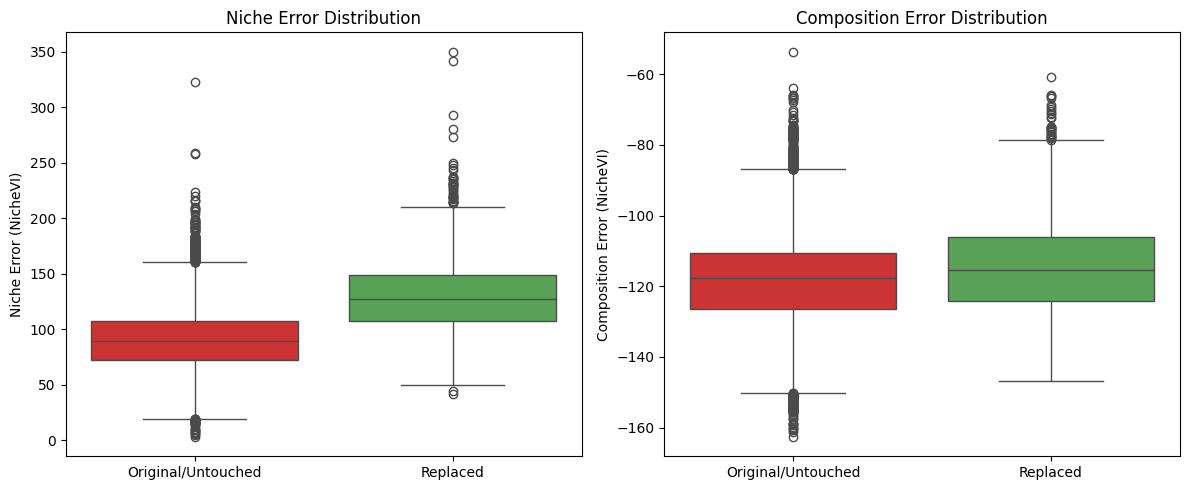

=== NICHE ERROR ===

count        mean        std        min         25%  \
Cell Type                                                                   
Original/Untouched  26856.0   90.318008  26.736986   2.732303   71.994610   
Replaced             3000.0  128.836151  32.732380  41.932823  106.959597   

                           50%         75%         max  
Cell Type                                               
Original/Untouched   89.415478  107.439882  322.487305  
Replaced            127.126678  148.568638  350.127808

=== COMPOSITION ERROR (absolute values) ===

count        mean        std        min         25%  \
Cell Type                                                                   
Original/Untouched  26856.0  118.726692  13.155800  53.600441  110.588749   
Replaced             3000.0  114.461227  13.477135  60.664604  105.987862   

                           50%         75%         max  
Cell Type                                               
Original/Untouched  117.520947  126.434870  162.646576  
Replaced            115.395485  124.240217  146.828979

In [7]:
# Create boxplots comparing niche error and composition error between replaced and non-replaced cells
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter to only astrocytes with the relevant error measurements
adata_astro_with_errors = adata_displaced[
    (adata_displaced.obs[LABEL] == target_cell_type) &
    (adata_displaced.obs["astrocyte_s10_scanvi_lr0.0005_poisson_niche_error"].notna())
].copy()

# Create a column indicating if cell has "_replaced" suffix
adata_astro_with_errors.obs["is_replaced"] = adata_astro_with_errors.obs_names.str.endswith("_replaced")

# Prepare data for plotting
niche_error_data = pd.DataFrame({
    "Error": adata_astro_with_errors.obs["astrocyte_s10_scanvi_lr0.0005_poisson_niche_error"],
    "Cell Type": adata_astro_with_errors.obs["is_replaced"].map({True: "Replaced", False: "Original/Untouched"}),
    "Error Type": "Niche Error"
})

compo_error_data = pd.DataFrame({
    "Error": adata_astro_with_errors.obs["astrocyte_s10_scanvi_lr0.0005_poisson_compo_error"],
    "Cell Type": adata_astro_with_errors.obs["is_replaced"].map({True: "Replaced", False: "Original/Untouched"}),
    "Error Type": "Composition Error"
})

# Combine both error types
combined_data = pd.concat([niche_error_data, compo_error_data], ignore_index=True)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Niche Error
sns.boxplot(
    data=niche_error_data,
    x="Cell Type",
    y="Error",
    ax=axes[0],
    palette=["#e41a1c", "#4daf4a"]
)
axes[0].set_title("Niche Error Distribution")
axes[0].set_ylabel("Niche Error (NicheVI)")
axes[0].set_xlabel("")

# Plot Composition Error
sns.boxplot(
    data=compo_error_data,
    x="Cell Type",
    y="Error",
    ax=axes[1],
    palette=["#e41a1c", "#4daf4a"]
)
axes[1].set_title("Composition Error Distribution")
axes[1].set_ylabel("Composition Error (NicheVI)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== NICHE ERROR ===")
print(niche_error_data.groupby("Cell Type")["Error"].describe())
print("\n=== COMPOSITION ERROR (absolute values) ===")
# Use absolute values for composition error since it's negative
compo_error_data["Abs Error"] = compo_error_data["Error"].abs()
print(compo_error_data.groupby("Cell Type")["Abs Error"].describe())

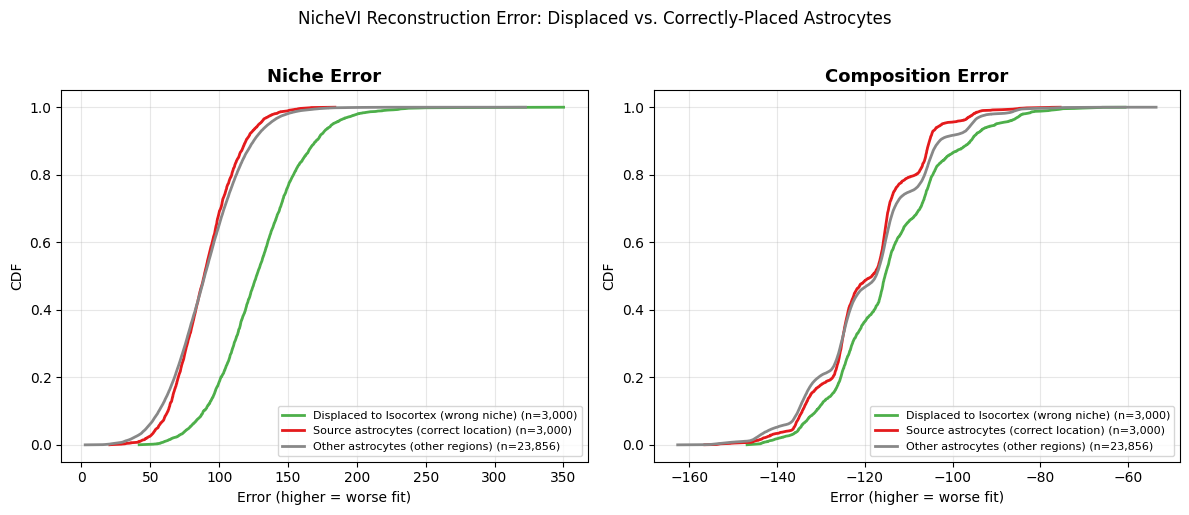

Niche Error: Mann-Whitney U p = 0.00e+00 (displaced > correct)

Composition Error: Mann-Whitney U p = 2.88e-51 (displaced > correct)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Filter to astrocytes with error measurements
adata_astro_with_errors = adata_displaced[
    (adata_displaced.obs[LABEL] == target_cell_type) &
    (adata_displaced.obs["astrocyte_s10_scanvi_lr0.0005_poisson_niche_error"].notna())
].copy()

error_cols = {
    "Niche Error":       "astrocyte_s10_scanvi_lr0.0005_poisson_niche_error",
    "Composition Error": "astrocyte_s10_scanvi_lr0.0005_poisson_compo_error",
}

groups = {
    "duplicated": ("#4daf4a", "Displaced to Isocortex (wrong niche)"),
    "original":   ("#e41a1c", "Source astrocytes (correct location)"),
    "untouched":  ("#888888", "Other astrocytes (other regions)"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, col) in zip(axes, error_cols.items()):
    for status, (color, label) in groups.items():
        mask = adata_astro_with_errors.obs["replacement_status"] == status
        vals = adata_astro_with_errors.obs.loc[mask, col].dropna().sort_values().values
        ecdf = np.arange(1, len(vals) + 1) / len(vals)
        ax.plot(vals, ecdf, label=f"{label} (n={len(vals):,})", color=color, lw=2)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Error (higher = worse fit)")
    ax.set_ylabel("CDF")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("NicheVI Reconstruction Error: Displaced vs. Correctly-Placed Astrocytes", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/astrocyte_error_cdf_comparison.png", bbox_inches="tight", dpi=300)
plt.savefig(f"{FIGURES_DIR}/astrocyte_error_cdf_comparison.svg", bbox_inches="tight", dpi=300)
plt.show()

# Mann-Whitney U: displaced > correctly placed?
for title, col in error_cols.items():
    displaced = adata_astro_with_errors.obs.loc[
        adata_astro_with_errors.obs["replacement_status"] == "duplicated", col
    ].dropna()
    correct = adata_astro_with_errors.obs.loc[
        adata_astro_with_errors.obs["replacement_status"].isin(["original", "untouched"]), col
    ].dropna()
    u, p = stats.mannwhitneyu(displaced, correct, alternative="greater")
    print(f"{title}: Mann-Whitney U p = {p:.2e} (displaced > correct)")